In [1]:
%pip install geopy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
from typing import Any, Self

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from geopy.distance import great_circle
from scipy import stats
from sklearn import ensemble, metrics, model_selection, tree

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", 10000)

pd.set_option("display.float_format", "{:.2f}".format)

### Первичный анализ

In [3]:
df = pd.read_parquet("data/taxi_data.parquet", engine="pyarrow")

display(df.info())
display(df.describe())
display(df.describe(include="object"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  pickup_holiday      1458644 non-null  int64         
 11  total_distance      1458643 non-null  float64       
 12  number_of_steps     1458643 non-null  float64       
 13  direction   

None

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_holiday,total_distance,number_of_steps,direction,geo_cluster,temperature,visibility,wind speed,precip
count,1458644.00,1458644,1458644.00,1458644.00,1458644.00,1458644.00,1458644.00,1458644.00,1458643.00,1458643.00,1458644.00,1458644.00,1446612.00,1446612.00,1446612.00,1446612.00
mean,1.53,2016-04-01 10:10:24.940037120,1.66,-73.97,40.75,-73.97,40.75,0.04,4626.38,7.55,-15.67,4.09,11.06,14.74,8.96,0.07
min,1.00,2016-01-01 00:00:17,0.00,-121.93,34.36,-121.93,32.18,0.00,0.00,2.00,-179.99,0.00,-18.30,0.40,0.00,0.00
25%,1.00,2016-02-17 16:46:04.249999872,1.00,-73.99,40.74,-73.99,40.74,0.00,1666.10,5.00,-125.27,0.00,3.90,16.10,5.60,0.00
50%,2.00,2016-04-01 17:19:40,1.00,-73.98,40.75,-73.98,40.75,0.00,2755.10,6.00,8.20,6.00,10.60,16.10,9.30,0.00
75%,2.00,2016-05-15 03:56:08.750000128,2.00,-73.97,40.77,-73.96,40.77,0.00,5113.80,9.00,53.40,7.00,18.00,16.10,13.00,0.00
max,2.00,2016-06-30 23:59:39,9.00,-61.34,51.88,-61.34,43.92,1.00,94204.20,46.00,180.00,9.00,32.20,16.10,137.00,11.90
std,0.50,NaN,1.31,0.07,0.03,0.07,0.04,0.18,5303.88,4.43,104.49,3.71,9.14,3.06,7.22,0.46


,id,dropoff_datetime,store_and_fwd_flag,events
count,1458644,1458644,1458644,71427
unique,1458644,1380377,2,3
top,id1209952,2016-05-16 19:40:28,N,Rain
freq,1,5,1450599,58300


In [4]:
dt_pickup_max = df["pickup_datetime"].max()
dt_pickup_min = df["pickup_datetime"].min()

print(
    f"Первое включение счетчика: {dt_pickup_min.date()} {dt_pickup_min.timetz()}\n"
    f"Крайнее включение счетчика: {dt_pickup_max.date()} {dt_pickup_max.timetz()}\n"
)

df["dropoff_datetime"] = df["dropoff_datetime"].astype("datetime64[ns]")
dt_dropoff_max = df["dropoff_datetime"].max()
dt_dropoff_min = df["dropoff_datetime"].min()

print(
    f"Первое выключение счетчика: {dt_dropoff_min.date()} {dt_dropoff_min.timetz()}\n"
    f"Крайнее выключение счетчика: {dt_dropoff_max.date()} {dt_dropoff_max.timetz()}\n"
)


if data_dupl := df.duplicated().sum():
    print(f"Найдено {data_dupl} дубликатов.")
    df = df.drop_duplicates()
    print("Все дубликаты удалены.")

for col in df.columns:
    if data_missing := df[col].isna().sum():
        print(f"В колонке {col} найдено {data_missing} пропусков.")

display(df["events"].value_counts())

Первое включение счетчика: 2016-01-01 00:00:17
Крайнее включение счетчика: 2016-06-30 23:59:39

Первое выключение счетчика: 2016-01-01 00:03:31
Крайнее выключение счетчика: 2016-07-01 23:02:03

В колонке total_distance найдено 1 пропусков.
В колонке number_of_steps найдено 1 пропусков.
В колонке temperature найдено 12032 пропусков.
В колонке visibility найдено 12032 пропусков.
В колонке wind speed найдено 12032 пропусков.
В колонке precip найдено 12032 пропусков.
В колонке events найдено 1387217 пропусков.


events
Rain    58300
Snow    13126
Fog         1
Name: count, dtype: int64

In [5]:
df = df.dropna(subset=["total_distance", "number_of_steps"])

df = df[df["events"] != "Fog"]

same_missing_mask = (
    df["temperature"].isna()
    & (df["visibility"].isna())
    & (df["wind speed"].isna())
    & (df["precip"].isna())
)

print(
    "Проверка, что это пропуски в одних и тех же строках:",
    same_missing_mask.sum(),
)

print(
    "Доля удаляемых данных от общего количества, %:",
    round(((df["temperature"].isna().sum() / df.shape[0]) * 100), 2)
)

df = df[~same_missing_mask]

Проверка, что это пропуски в одних и тех же строках: 12032
Доля удаляемых данных от общего количества, %: 0.82


In [6]:
def custom_event_inputter(row: pd.Series) -> str:
    """Выбор погодного условия исходя из параметров."""
    if pd.notna(row["events"]):
        return row["events"]

    if pd.isna(row["precip"]) or row["precip"] == 0:
        return "No_precipitation"

    if pd.isna(row["temperature"]):
        return np.nan

    if row["temperature"] < 0:
        return "Snow"
    else:
        return "Rain"

df["events"] = df.apply(custom_event_inputter, axis=1)
df["events"].value_counts()

events
No_precipitation    1341361
Rain                  92123
Snow                  13126
Name: count, dtype: int64

In [7]:
print("Финальная проверка на пропуски после предобработки.\n")

for col in df.columns:
    if data_missing := df[col].isna().sum():
        print(f"В колонке {col} найдено {data_missing} пропусков.")

print("Итого пропусков:", df.isna().sum())

Финальная проверка на пропуски после предобработки.

Итого пропусков: id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
pickup_holiday        0
total_distance        0
number_of_steps       0
direction             0
geo_cluster           0
temperature           0
visibility            0
wind speed            0
precip                0
events                0
dtype: int64


**Вывод:**  
- данные представлены за период с `2016-01-01` по `2016-07-01`
- полных дубликатов строк не найдено
- большая часть данных пропущено в `events`. Логика заполнения следующая: если в строке есть данные о количестве осадков, значит они были, иначе `No_precipitation` --> в зависимости от температуры это либо `Snow`, либо `Rain`
- ситуация с `Fog` такая: есть только одна запись о таком событии и только на её основании невозможно связать в паттерн `осадки/температуру/видимость` для корректного заполнения пробелов (можно попробовать использовать некий порог по `precip/temperature/visibility` и по ним присваивать случайно либо `Fog`, либо `Rain`)
- было решено удалить `12032 строк`, так как все полученные пропуски содержатся именно в этих строках. Но так как отсутствуют все погодные признаки, то восстановить погодные условия практически невозможно

### Преобразование признаков

In [8]:
df["target"] = (df["dropoff_datetime"] - df["pickup_datetime"]).dt.seconds
display(df[["target"]].head())

df["hour"] = df["pickup_datetime"].dt.hour
df["day"] = df["pickup_datetime"].dt.day
df["weekday"] = df["pickup_datetime"].dt.weekday
df["month"] = df["pickup_datetime"].dt.month

display(df[["hour", "day", "weekday", "month"]].head())

,target
0,455
1,663
2,2124
3,429
4,435


,hour,day,weekday,month
0,17,14,0,3
1,0,12,6,6
2,11,19,1,1
3,19,6,2,4
4,13,26,5,3


In [9]:
def two_point_dist(row: pd.Series) -> float:
    """Расстояние между двумя точками: местом посадки в такси и местом высадки."""
    pickup = (row["pickup_latitude"], row["pickup_longitude"])
    dropoff = (row["dropoff_latitude"], row["dropoff_longitude"])
    return great_circle(pickup, dropoff).m

df["two_point_dist"] = df.apply(two_point_dist, axis=1)
df[["two_point_dist"]].head()

,two_point_dist
0,1498.52
1,1805.51
2,6385.11
3,1485.50
4,1188.59


In [10]:
uninfo_features = [
    "id", "store_and_fwd_flag",
    "pickup_datetime", "direction",
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude",
]

leak_features = [
    "dropoff_datetime", "total_distance",
    "number_of_steps",
]

df = df.drop(columns=uninfo_features + leak_features)
df.head()

,vendor_id,passenger_count,pickup_holiday,geo_cluster,temperature,visibility,wind speed,precip,events,target,hour,day,weekday,month,two_point_dist
0,2,1,0,6,4.40,8.00,27.80,0.30,Rain,455,17,14,0,3,1498.52
1,1,1,0,9,28.90,16.10,7.40,0.00,No_precipitation,663,0,12,6,6,1805.51
2,2,1,0,9,-6.70,16.10,24.10,0.00,No_precipitation,2124,11,19,1,1,6385.11
3,2,1,0,9,7.20,16.10,25.90,0.00,No_precipitation,429,19,6,2,4,1485.50
4,2,1,0,6,9.40,16.10,9.30,0.00,No_precipitation,435,13,26,5,3,1188.59


**Вывод:**  
- длительность поездки считаю как разницу во времени между фиксацией высадки и посадкой, преобразовав итог в секунды
- признаки в список`uninfo_features` включены по следующим причинам: `id и store_and_fwd_flag` не несут никакой информации; `pickup_datetime` уже преобразован в отдельные признаки; признаки долготы/широты точек преобразованы в один признак `two_point_dist` - истинное расстояние между координатами (использовал библиотеку `geopy`), в метрах т.к. везде используется стандартная СИ; `direction` не потребовался
- признаки в списке `leak_features`: содержат информаию, которую невозможно получить до конца поездки и косвенно содержит необходимые сведения для целевой переменной

### Исследование статистики признаков

In [11]:
before_dropped = df.shape[0]
dropped_counter = 0

num_features = [col for col in df.columns if col != "events"]
df[num_features].describe()

,vendor_id,passenger_count,pickup_holiday,geo_cluster,temperature,visibility,wind speed,precip,target,hour,day,weekday,month,two_point_dist
count,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00,1446610.00
mean,1.53,1.66,0.04,4.09,11.06,14.74,8.96,0.07,952.85,13.64,15.56,3.04,3.51,3440.22
std,0.50,1.31,0.18,3.71,9.14,3.06,7.22,0.46,3174.62,6.38,8.70,1.95,1.68,4299.58
min,1.00,0.00,0.00,0.00,-18.30,0.40,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00
25%,1.00,1.00,0.00,0.00,3.90,16.10,5.60,0.00,397.00,9.00,8.00,1.00,2.00,1231.65
50%,2.00,1.00,0.00,6.00,10.60,16.10,9.30,0.00,662.00,14.00,15.00,3.00,4.00,2092.92
75%,2.00,2.00,0.00,7.00,18.00,16.10,13.00,0.00,1075.00,19.00,23.00,5.00,5.00,3873.21
max,2.00,9.00,1.00,9.00,32.20,16.10,137.00,11.90,86392.00,23.00,31.00,6.00,6.00,1240910.43


Записей с аномальным количеством пассажиров: 5


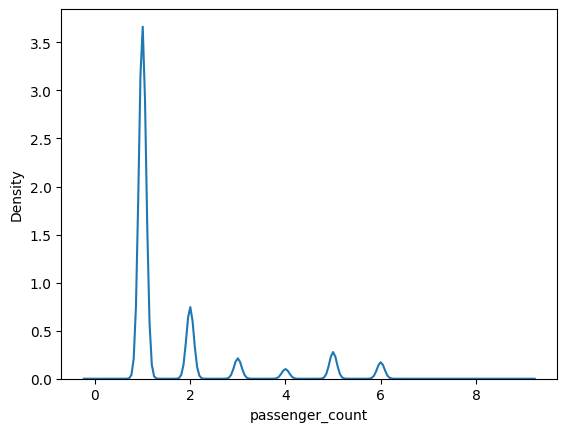

In [12]:
sns.kdeplot(data=df, x="passenger_count")

passenger_count_mask = df["passenger_count"] >= 7
passenger_drop_count = passenger_count_mask.sum()
dropped_counter += passenger_drop_count

print("Записей с аномальным количеством пассажиров:", passenger_drop_count)

df = df[~passenger_count_mask]

,median,mean,min,max
month,,,,
1,2.20,2.04,-11.70,15.00
2,3.30,3.21,-18.30,16.10
3,9.40,9.47,-3.30,25.60
4,11.70,11.87,-3.30,27.20
5,16.10,16.99,6.00,32.20
6,22.20,22.60,11.10,30.60


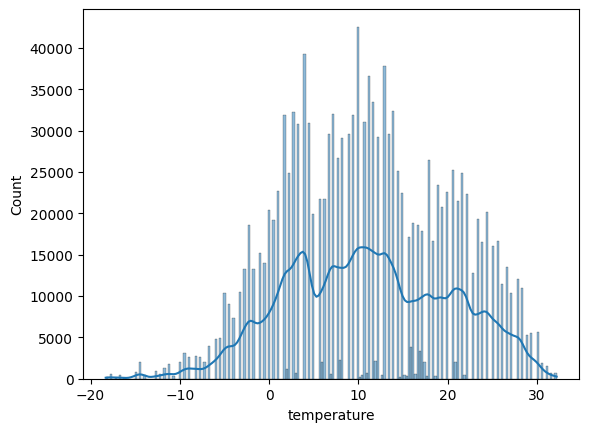

In [13]:
sns.histplot(data=df, x="temperature", kde=True)

month_temperature = df.groupby("month")["temperature"].agg(["median", "mean", "min", "max"])
month_temperature

Значение для квантиля уровня 0.995: 29.6
Аномальных значений, выше заданного уровня: 7012


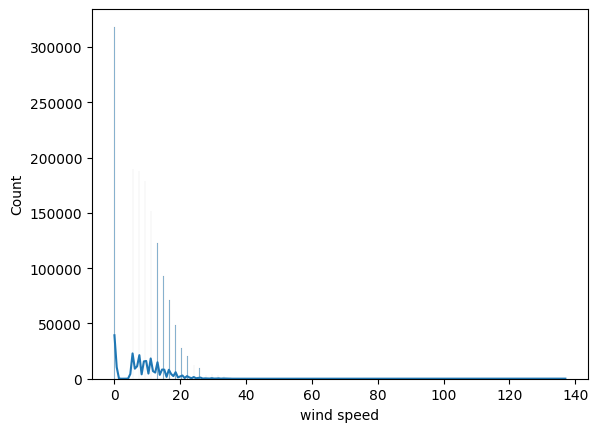

In [14]:
sns.histplot(data=df, x="wind speed", kde=True)

wind_q = df["wind speed"].quantile(0.995)
wind_drop_count = df[df["wind speed"] > wind_q].shape[0]
dropped_counter += wind_drop_count

print("Значение для квантиля уровня 0.995:", wind_q)
print("Аномальных значений, выше заданного уровня:", wind_drop_count)

df = df[df["wind speed"] <= wind_q]

Значение для квантиля уровня 0.999: 24782.11830332401
Аномальных значений, выше заданного уровня: 1440


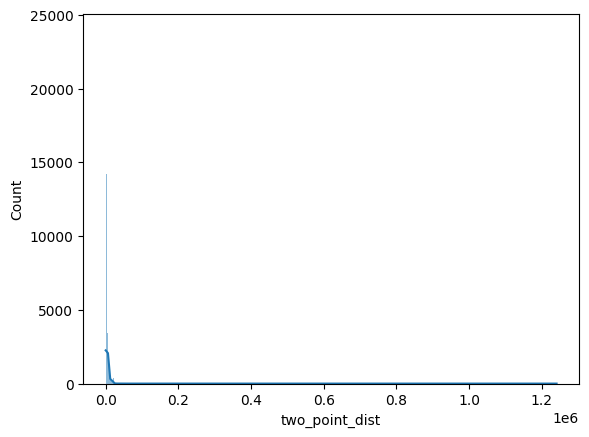

In [15]:
sns.histplot(data=df, x="two_point_dist", kde=True)

dist_q = df["two_point_dist"].quantile(0.999)
dist_drop_count = df[df["two_point_dist"] > dist_q].shape[0]
dropped_counter += dist_drop_count

print("Значение для квантиля уровня 0.999:", dist_q)
print("Аномальных значений, выше заданного уровня:", dist_drop_count)

df = df[df["two_point_dist"] <= dist_q]

In [16]:
DROPPED_THRESHOLD = 1
another_drop_rate = round(((dropped_counter / before_dropped) * 100), 2)

print("Процент удаленных данных после избавления от выбросов/аномалий:", another_drop_rate)

if another_drop_rate > DROPPED_THRESHOLD:
    print(f"Перестарался, надо меньше {DROPPED_THRESHOLD}%")
else:
    print(f"Убрал в рамках положенного {DROPPED_THRESHOLD}%")

Процент удаленных данных после избавления от выбросов/аномалий: 0.58
Убрал в рамках положенного 1%


**Вывод:**  
-  `passenger_count`: больше 6 пассажиров в такси является редким событием, но довольно аномальным, потому удалены
- `temperature`: распределение выглядит нормальным, значения по месяцам тоже. Не знаю, действительно ли в рамках Нью-Йорка могут быть такие колебания, но ничего удивительного
- `wind speed`: 30 м/с - адекватный верхний порог, полученный по квантилю уровня 0.995, где выше - уже близкая к урагану ситуация
- `two_point_dist`: ~25км - основное расстояние между двумя пунктами назначения по квантилю уровня 0.999. Большее расстояние крайне редкое событие, которое, скорее всего, просто ошибочное
- `vendor_id`, `pickup_holiday`, `geo_cluster`, `visibility`, `precip` и признаки атрибутов времени/даты: их данные соответствуют ожидаемым, отрицательных значений нет

### Распределение и выбросы

In [17]:
def simple_feature_stats(df: pd.DataFrame, col_name: str) -> None:
    """Вывод основной статистики по признаку."""
    mean = df[col_name].mean()
    std = df[col_name].std()
    skew = df[col_name].skew()
    kurt = df[col_name].kurt()

    print(
        f"Статистика для {col_name}:\n"
        f"Среднее: {mean:.2f}\n"
        f"Стандартное отклонение: {std:.2f}\n"
        f"Скос: {skew:.2f}\n"
        f"Смещение: {kurt:.2f}\n"
    )

Статистика для target:
Среднее: 950.66
Стандартное отклонение: 3171.36
Скос: 25.28
Смещение: 667.17



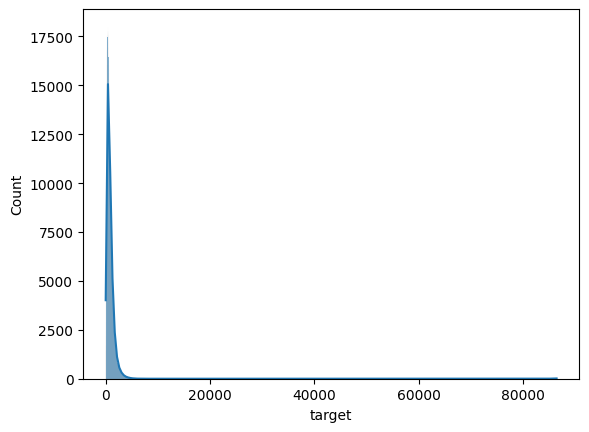

In [18]:
sns.histplot(data=df, x="target", kde=True)

simple_feature_stats(df, "target")

In [19]:
target_q = df["target"].quantile(0.999)

print(f"Квантиль уровня 0.999 для target: {target_q:.2f}")

rows_before = df.shape[0]
extreme_targets = df[df["target"] > target_q].shape[0]

print(f"Строк с target > {target_q:.2f}: {extreme_targets}")
print(f"{extreme_targets/rows_before*100:.2f}% данных")

df = df[df["target"] <= target_q]

target_log = df["target"].apply(np.log1p)
df["target_log"] = target_log

Квантиль уровня 0.999 для target: 85117.00
Строк с target > 85117.00: 1438
0.10% данных


Статистика для target_log:
Среднее: 6.46
Стандартное отклонение: 0.78
Скос: -0.54
Смещение: 2.83



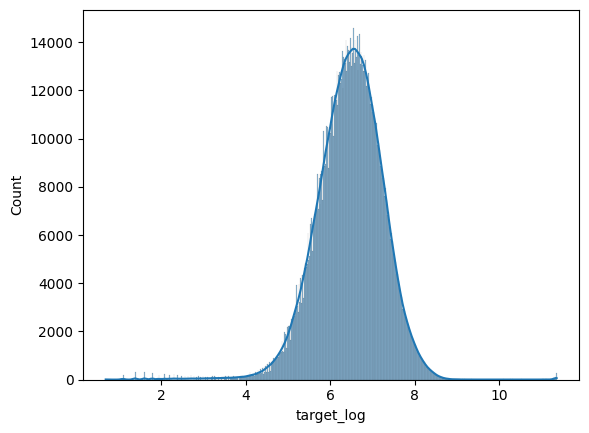

In [20]:
sns.histplot(data=df, x="target_log", kde=True)

simple_feature_stats(df, "target_log")

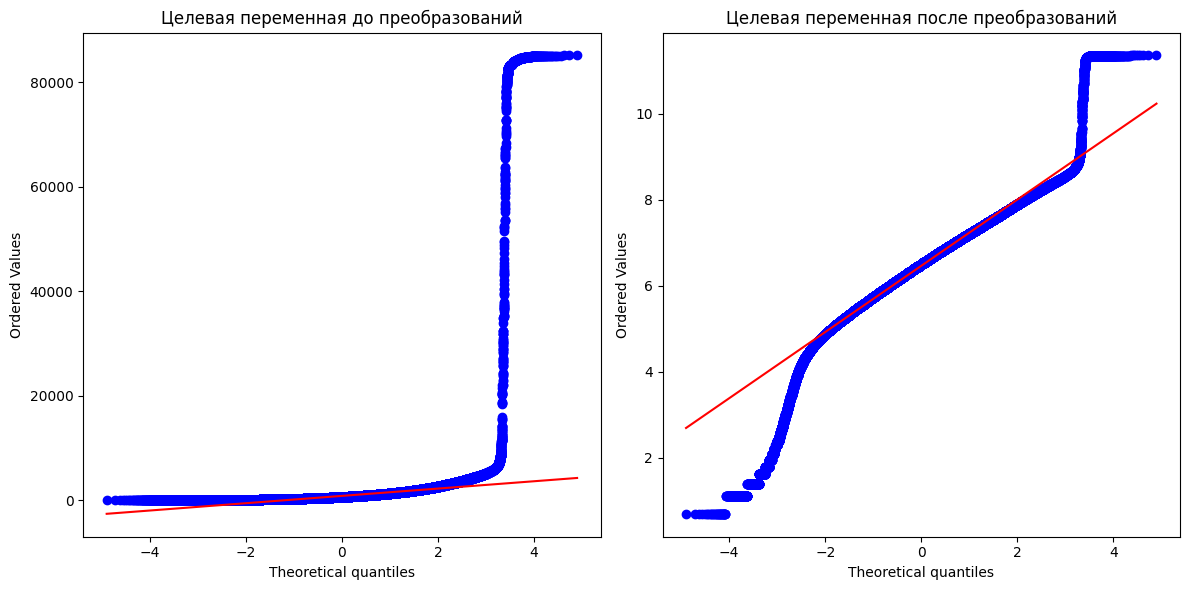

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

stats.probplot(df["target"], dist="norm", plot=axes[0])
axes[0].set_title("Целевая переменная до преобразований")

stats.probplot(df["target_log"], dist="norm", plot=axes[1])
axes[1].set_title("Целевая переменная после преобразований")

plt.tight_layout()
plt.show()

In [22]:
df = df.drop(columns=["target"])

**Вывод:**  
- `target` до преобразования: сильное правостороннее распределение `25.28` (длинный правый хвост), экстримальная островершинность `667.17`, стандартное отклонение больше среднего в 3 раза
- как и в случае с `two_point_dist`, убрал самые экстримальные значения по квантилю уровня `0.999`, пожертвовав 0.1% данных; затем, сгладил распределение логарифмированием
- `target` после преобразования: распределение стало очень близким к нормальному; небольшая левосторонняя асимметрия `-0.54`; более плосковершинное `2.83`, чем нормальное

### Исследование временных зависимостей

<Axes: xlabel='hour', ylabel='target_log'>

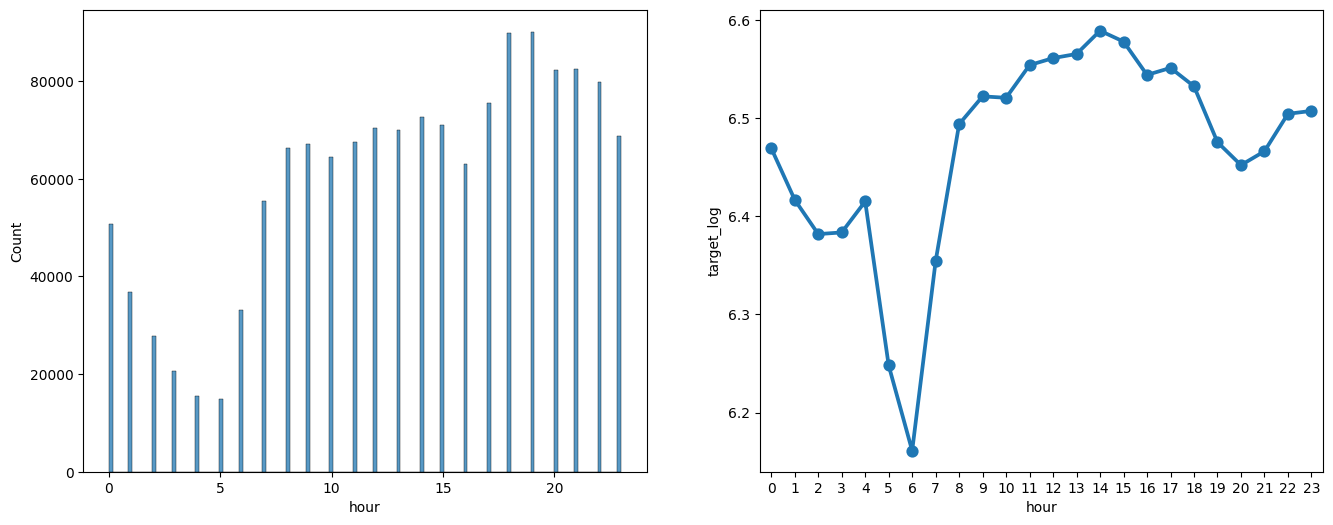

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x="hour", ax=axes[0])

sns.pointplot(
    x="hour", 
    y="target_log",
    data=df,
    estimator=np.median,
    errorbar=None,
    ax=axes[1],
)

<Axes: xlabel='weekday', ylabel='target_log'>

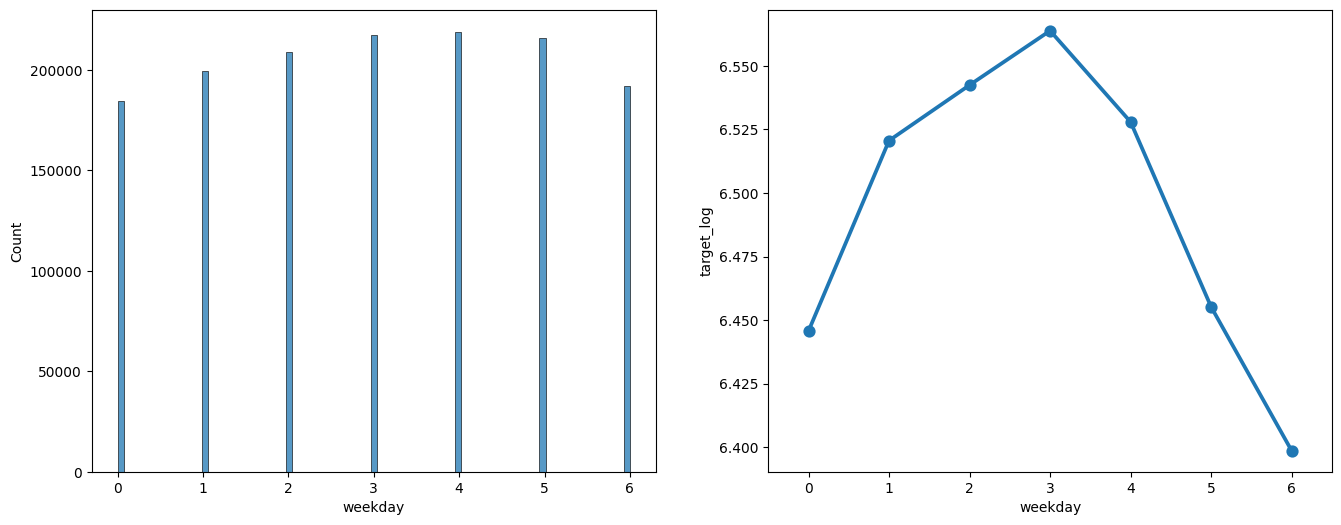

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x="weekday", ax=axes[0])

sns.pointplot(
    x="weekday", 
    y="target_log",
    data=df,
    estimator=np.median,
    errorbar=None,
    ax=axes[1],
)

<Axes: ylabel='hour'>

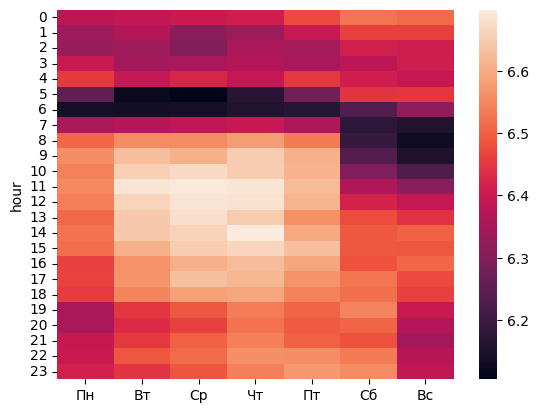

In [25]:
pivot = df.pivot_table(
    values="target_log",
    index="hour",
    columns="weekday",
    aggfunc="median",
)

day_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
pivot.columns = day_names

sns.heatmap(pivot)

**Вывод:**  
Результаты выглядят логично. Ранним утром количество заказов меньше, чем в остальные часы, а время в пути низкое (отсутствие пробок, интенсивного движения и других условий); это так же касается и распределения по дням недели - при относительно равном количество заказов в каждом из день недели, именно в выходные наблюдается минимум на время в пути; и вполне ожидаемо, наибольшая концентрация медианы затраченного на путь времени приходится на будние (рабочие) дни с ~09:00 до ~19:00 (в особенности в околообеденное время)

### Кодирование признаков и разделение данных

In [26]:
display(df["geo_cluster"].value_counts())

rare_clusters = [1, 4, 5]
rare_clusters_indx = df[df["geo_cluster"].isin(rare_clusters)].index

df = df.drop(index=rare_clusters_indx)

geo_cluster
0    587656
6    399543
9    317916
7     44882
3     40105
2     31533
8     15072
4         3
5         3
1         2
Name: count, dtype: int64

In [27]:
df = pd.get_dummies(df, columns=["vendor_id"], prefix="vendor")
df = pd.get_dummies(df, columns=["geo_cluster"], prefix="cluster")
df = pd.get_dummies(df, columns=["events"], prefix="event")

display(df.head(1))

,passenger_count,pickup_holiday,temperature,visibility,wind speed,precip,hour,day,weekday,month,two_point_dist,target_log,vendor_1,vendor_2,cluster_0,cluster_2,cluster_3,cluster_6,cluster_7,cluster_8,cluster_9,event_No_precipitation,event_Rain,event_Snow
0,1,0,4.40,8.00,27.80,0.30,17,14,0,3,1498.52,6.12,False,True,False,False,False,True,False,False,False,False,True,False


In [28]:
y = df[["target_log"]]
X = df.drop(columns=["target_log"])

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42,
)

display(X_train.head(1))
display(y_train.head(1))

,passenger_count,pickup_holiday,temperature,visibility,wind speed,precip,hour,day,weekday,month,two_point_dist,vendor_1,vendor_2,cluster_0,cluster_2,cluster_3,cluster_6,cluster_7,cluster_8,cluster_9,event_No_precipitation,event_Rain,event_Snow
1258610,1,0,26.70,14.50,0.00,0.00,18,26,6,6,1198.89,False,True,True,False,False,False,False,False,False,True,False,False


,target_log
1258610,5.11


**Вывод:**  
- чтобы не добавлять лишнюю размерность и снизить шум, убрал очень редкие геокластеры
- для `vendor_id`, `geo_cluster`, `events` применил One-hot кодировнание Pandas - это добавило 12 новых признаков минус 3 изначальных = итого 9, что приемлемо и значительно не повысило размерность

### Ручная реализация и сравнение с готовым классом

In [29]:
def get_metrics(y_true, y_pred):
    """Вывод метрик регрессии."""
    print("\nВ лог-шкале целевой переменной:")
    print(f"MAE: {metrics.mean_absolute_error(y_true, y_pred):.4f}")
    print(f"MSE: {metrics.mean_squared_error(y_true, y_pred):.4f}")
    print(f"R^2: {metrics.r2_score(y_true, y_pred):.4f}")

    y_true_loginv = np.expm1(y_true)
    y_pred_loginv = np.expm1(y_pred)

    print("\nВ инвертированной шкале:")
    print(f"MAE: {metrics.mean_absolute_error(y_true_loginv, y_pred_loginv):.4f}")
    print(f"MSE: {metrics.mean_squared_error(y_true_loginv, y_pred_loginv):.4f}")

In [30]:
class SimpleDecisionTreeRegressor:
    """Простая реализация решающего дерева для регрессии."""
    def __init__(
        self,
        criterion: str = "squared_error",
        max_depth: int | None = None,
        min_samples_leaf: int = 1,
    ) -> None:

        assert criterion in ("squared_error", "absolute_error")

        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.tree_ = None

    def _mse(self, y) -> float:
        if len(y) == 0:
            return 0.0
        return np.var(y)

    def _mae(self, y) -> float:
        if len(y) == 0:
            return 0.0
        return np.mean(np.abs(y - np.median(y)))

    def _impurity(self, y) -> float:
        if len(y) == 0:
            return 0.0

        if self.criterion == "squared_error":
            return self._mse(y)
        else:
            return self._mae(y)

    def _leaf_value(self, y) -> float:
        if self.criterion == "squared_error":
            return float(np.mean(y))
        else:
            return float(np.median(y))

    def _best_split(self, X: np.ndarray, y: np.ndarray):

        n_samples, n_features = X.shape

        if n_samples <= 1:
            return None, None, None, None

        parent_impurity = self._impurity(y)
        best_gain = 0.0
        best_feat = None
        best_thresh = None
        best_left_mask = None

        for feature in range(n_features):
            values = X[:, feature]
            sorted_idx = np.argsort(values)
            values_sorted = values[sorted_idx]
            y_sorted = y[sorted_idx]

            for i in range(1, n_samples):

                if values_sorted[i] == values_sorted[i - 1]:
                    continue

                left_count = i
                right_count = n_samples - i

                if (
                    left_count < self.min_samples_leaf
                    or right_count < self.min_samples_leaf
                ):
                    continue

                thresh = (values_sorted[i] + values_sorted[i - 1]) / 2.0

                left_y = y_sorted[:i]
                right_y = y_sorted[i:]

                left_imp = self._impurity(left_y)
                right_imp = self._impurity(right_y)

                weighted_imp = (
                    left_count * left_imp
                    + right_count * right_imp
                ) / n_samples

                gain = parent_impurity - weighted_imp

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feature
                    best_thresh = thresh
                    best_left_mask = values <= thresh

        return best_feat, best_thresh, best_left_mask, best_gain

    def _build_tree(
        self,
        X: np.ndarray,
        y: np.ndarray,
        depth=0,
    ) -> dict[str, Any]:

        num_samples = X.shape[0]

        node: dict[str, Any] = {
            "n_samples": num_samples,
            "value": self._leaf_value(y),
            "is_leaf": False,
        }

        if self.max_depth is not None and depth >= self.max_depth:
            node["is_leaf"] = True
            return node

        if num_samples < 2 * self.min_samples_leaf:
            node["is_leaf"] = True
            return node

        feat, thresh, left_mask, gain = self._best_split(X, y)

        if feat is None or gain <= 1e-12:
            node["is_leaf"] = True
            return node

        node["feature"] = int(feat)
        node["threshold"] = float(thresh)

        node["left"] = self._build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1,
        )

        node["right"] = self._build_tree(
            X[~left_mask],
            y[~left_mask],
            depth + 1,
        )

        return node

    def fit(
        self,
        X: np.ndarray | pd.DataFrame,
        y: np.ndarray | pd.Series | pd.DataFrame,
    ) -> Self:

        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()

        if isinstance(y, (pd.Series, pd.DataFrame)):
            y = np.asarray(y).ravel()
        else:
            y = np.asarray(y)

        self.n_features_ = X.shape[1]

        self.tree_ = self._build_tree(X, y, depth=0)

        return self

    def _predict_one(self, x, node: dict[str, Any]) -> float:

        if node.get("is_leaf", True):
            return node["value"]

        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def predict(
        self,
        X: np.ndarray | pd.DataFrame,
    ) -> np.ndarray:

        if self.tree_ is None:
            raise ValueError(
                "Модель ещё не обучена. "
                "Сначала вызовите fit()."
            )

        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()

        return np.array([
            self._predict_one(x, self.tree_) for x in X
        ])

In [31]:
ROW_SIZE_LIMITER = 100_000
X_train_lim = X_train[:ROW_SIZE_LIMITER]
X_test_lim = X_test[:ROW_SIZE_LIMITER]
y_train_lim = y_train[:ROW_SIZE_LIMITER]
y_test_lim = y_test[:ROW_SIZE_LIMITER]

simple_tree = SimpleDecisionTreeRegressor()
simple_tree.fit(X_train_lim, y_train_lim)

y_pred_train = simple_tree.predict(X_train_lim)
y_pred_test = simple_tree.predict(X_test_lim)

sk_tree_model = tree.DecisionTreeRegressor()
sk_tree_model.fit(X_train_lim, y_train_lim)

y_pred_sk_train = simple_tree.predict(X_train_lim)
y_pred_sk_test = simple_tree.predict(X_test_lim)

In [32]:
print("Показатели ручной реализации дерева.")
print("На обучающей выборке:")
get_metrics(y_train_lim, y_pred_train)
print("На тестовой выборке:")
get_metrics(y_test_lim, y_pred_test)

print("\nПоказатели реализации дерева из sklearn.")
print("На обучающей выборке:")
get_metrics(y_train_lim, y_pred_sk_train)
print("На тестовой выборке:")
get_metrics(y_test_lim, y_pred_sk_test)

Показатели ручной реализации дерева.
На обучающей выборке:

В лог-шкале целевой переменной:
MAE: 0.0000
MSE: 0.0000
R^2: 1.0000

В инвертированной шкале:
MAE: 0.0049
MSE: 1.2504
На тестовой выборке:

В лог-шкале целевой переменной:
MAE: 0.4329
MSE: 0.3669
R^2: 0.3950

В инвертированной шкале:
MAE: 382.5021
MSE: 5533498.3009

Показатели реализации дерева из sklearn.
На обучающей выборке:

В лог-шкале целевой переменной:
MAE: 0.0000
MSE: 0.0000
R^2: 1.0000

В инвертированной шкале:
MAE: 0.0049
MSE: 1.2504
На тестовой выборке:

В лог-шкале целевой переменной:
MAE: 0.4329
MSE: 0.3669
R^2: 0.3950

В инвертированной шкале:
MAE: 382.5021
MSE: 5533498.3009


**Вывод:**  
Присутствует сильное переобучение: модель идеально запомнила обучающую выборку (`R^2 = 1.0`, `MAE = 0` в лог-шкале), но значительно хуже показывает результат на тестовых данных (`R^2 = 0.395` на тесте). Модель не выявила общую закономерность, а просто выучила данные.

### Подбор параметра глубины дерева и визуализация

In [33]:
results = []
for depth in np.arange(5, 16):
    sk_tree_model = tree.DecisionTreeRegressor(max_depth=depth)
    sk_tree_model.fit(X_train, y_train)

    y_pred_train = sk_tree_model.predict(X_train)
    y_pred_test = sk_tree_model.predict(X_test)

    results.append({
        "depth": depth,
        "mae_train": metrics.mean_absolute_error(y_train, y_pred_train),
        "mae_test": metrics.mean_absolute_error(y_test, y_pred_test),
        "mse_train": metrics.mean_squared_error(y_train, y_pred_train),
        "mse_test": metrics.mean_squared_error(y_test, y_pred_test),
        "R^2_train": metrics.r2_score(y_train, y_pred_train),
        "R^2_test": metrics.r2_score(y_test, y_pred_test),        
    })

In [34]:
tree_df = pd.DataFrame(results)
tree_df = tree_df.sort_values("R^2_test", ascending=False)
tree_df

,depth,mae_train,mae_test,mse_train,mse_test,R^2_train,R^2_test
6,11,0.30,0.30,0.18,0.18,0.71,0.70
5,10,0.30,0.30,0.18,0.18,0.71,0.70
7,12,0.30,0.30,0.17,0.18,0.72,0.70
4,9,0.31,0.31,0.18,0.18,0.70,0.70
8,13,0.29,0.30,0.17,0.19,0.73,0.69
3,8,0.31,0.31,0.19,0.19,0.69,0.69
9,14,0.29,0.30,0.16,0.19,0.74,0.69
2,7,0.32,0.32,0.19,0.19,0.68,0.68
10,15,0.28,0.31,0.15,0.20,0.75,0.68
1,6,0.33,0.33,0.20,0.20,0.67,0.66


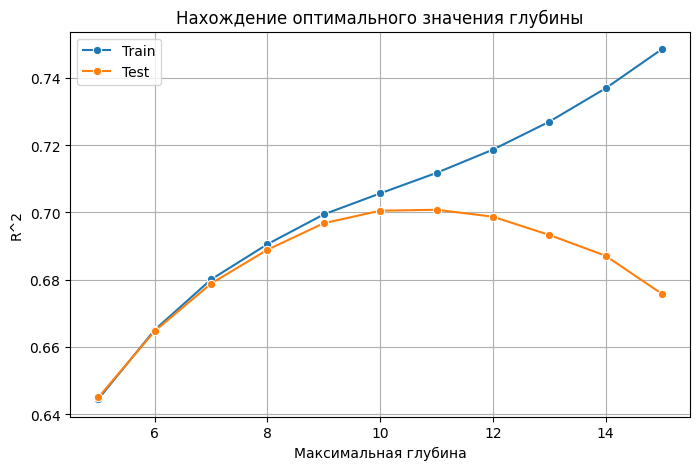

In [35]:
plt.figure(figsize=(8,5))

sns.lineplot(data=tree_df, x="depth", y="R^2_train", marker="o", label="Train")
sns.lineplot(data=tree_df, x="depth", y="R^2_test", marker="o", label="Test")

plt.xlabel("Максимальная глубина")
plt.ylabel("R^2")
plt.title("Нахождение оптимального значения глубины")

plt.grid(True)
plt.show()

**Вывод:**  
Модель удалось стабилизировать, подобрав нужное значение максимальной глубины дерева:  
- исходная модель (без ограничения глубины) имела `R^2_test = 0.395` и `MAE_test = 0.4329`
- новая модель с оптимальной глубиной `11` показывает `R^2_test = 0.70` и `MAE_test = 0.30`

Точность выросла, а разрыв между `train и test` сократился `0.71 / 0.70`

### Модель "Случайного леса" из sklearn

In [36]:
forest_model = ensemble.RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
)

forest_model.fit(X_train, y_train["target_log"])

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred_train = forest_model.predict(X_train)
y_pred_test = forest_model.predict(X_test)

print("Показатели случайного леса из sklearn.")

print("На обучающей выборке:")
get_metrics(y_train, y_pred_train)

print("\nНа тестовой выборке:")
get_metrics(y_test, y_pred_test)

Показатели случайного леса из sklearn.
На обучающей выборке:

В лог-шкале целевой переменной:
MAE: 0.1162
MSE: 0.0278
R^2: 0.9543

В инвертированной шкале:
MAE: 110.5141
MSE: 1572108.3745

На тестовой выборке:

В лог-шкале целевой переменной:
MAE: 0.3093
MSE: 0.1911
R^2: 0.6853

В инвертированной шкале:
MAE: 251.8210
MSE: 2646765.5103


**Вывод:**  
- на обучающей выборке `(R^2 = 0.9543, MAE = 0.1162)` значения превосходят тестовые `(R^2 = 0.6853, MAE = 0.3093)` - модель переобучена
- ранее, лучшее дерево решений с подобранной глубиной показало `R^2 = 0.70 и MAE = 0.30` на тесте, случайный лес продемонстрировал сопоставимые результаты, но хуже

### Оценка значимости признаков

In [38]:
feature_importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": forest_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df

,feature,importance
0,two_point_dist,0.73
1,hour,0.06
2,temperature,0.04
3,day,0.03
4,weekday,0.03
5,wind speed,0.02
6,passenger_count,0.02
7,month,0.01
8,cluster_6,0.01
9,vendor_1,0.01


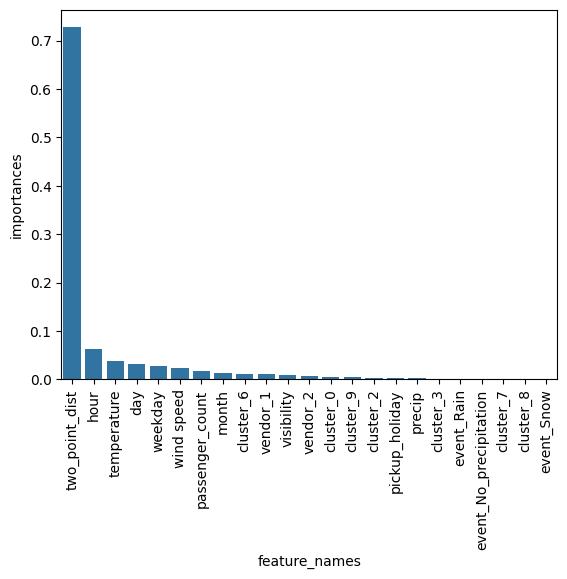

In [39]:
sns.barplot(feature_importance_df, x="feature", y="importance")

plt.xlabel("feature_names")
plt.ylabel("importances")
plt.xticks(rotation=90)

plt.show()

In [40]:
TOP_NUM = 5

print(f"Топ-{TOP_NUM} наиболее значимых признаков:")
feature_importance_df[:TOP_NUM]

Топ-5 наиболее значимых признаков:


,feature,importance
0,two_point_dist,0.73
1,hour,0.06
2,temperature,0.04
3,day,0.03
4,weekday,0.03


Результаты выглядят вполне обоснованно. После расстояния, которое является основным ценообразующим фактором, модель выделяет временные параметры (hour, day, weekday) и погодные условия (temperature), что отражает реальное влияние спроса и условий на тарифы (например, часы пик, погода). Остальные признаки (кластеры, события) вносят незначительный вклад.

**Вывод:**  
- расстояние между двумя точками маршрута, конечно, напрямую влияет на время поездки и его вклад самый большой `0.73`
- далее по важности следуют атрибуты даты и времени `(weekday day hour)`, а так же `temperature`, которая так или иначе влияет на погодные условия
- совокупно эти признаки отражают реальную картину влияния на время поездки в такси